In [1]:

# Now check the existing data structure more clearly
print("Existing GEV results for zeta:")
print(f" ξ_zeta: {gev_results['zeta']['xi']:.6f}")
print(f" 95% CI: [{gev_results['zeta']['ci_xi'][0]:.6f}, {gev_results['zeta']['ci_xi'][1]:.6f}]")
print(f" μ_zeta: {gev_results['zeta']['mu']:.6f}")
print(f" σ_zeta: {gev_results['zeta']['sigma']:.6f}")
print(f" KS p-value: {gev_results['zeta']['ks_pvalue']:.4f}")


Existing GEV results for zeta:
 ξ_zeta: -0.136484
 95% CI: [-0.263474, 0.015299]
 μ_zeta: 10.439755
 σ_zeta: 1.732331
 KS p-value: 0.8192


In [2]:

# Step 1: Generate L_DH partial sum values using corrected squarefree implementation
# We need to compute D_DH(t; N=10^5) for t in [1000, 10000]

def mobius(n):
 """Compute the Möbius function μ(n)"""
 if n == 1:
 return 1
 
 # Factor n and check for repeated prime factors
 factors = []
 temp = n
 d = 2
 while d * d <= temp:
 exp = 0
 while temp % d == 0:
 temp //= d
 exp += 1
 if exp > 0:
 if exp > 1: # Squared prime factor
 return 0
 factors.append(d)
 d += 1
 if temp > 1:
 factors.append(temp)
 
 # μ(n) = (-1)^k for squarefree n with k distinct prime factors
 return (-1) ** len(factors)

def is_squarefree(n):
 """Check if n is squarefree (μ(n) ≠ 0)"""
 return mobius(n) != 0

# Generate L_DH coefficients for n ≤ N
N = 100000
print(f"Generating L_DH coefficients for n ≤ {N}...")

# Pre-compute all Möbius values
mobius_values = np.zeros(N + 1, dtype=np.int8)
for n in range(1, N + 1):
 mobius_values[n] = mobius(n)

# L_DH coefficients: a_n = λ(n) * μ(n) where λ(n) is the Liouville function
# λ(n) = (-1)^Ω(n) where Ω(n) is the number of prime factors counted with multiplicity
def compute_liouville(n):
 """Compute the Liouville function λ(n) = (-1)^Ω(n)"""
 if n == 1:
 return 1
 omega = 0
 temp = n
 d = 2
 while d * d <= temp:
 while temp % d == 0:
 temp //= d
 omega += 1
 d += 1
 if temp > 1:
 omega += 1
 return (-1) ** omega

# Generate L_DH coefficients
a_DH = np.zeros(N + 1, dtype=np.float64)
print("Computing L_DH coefficients...")
for n in range(1, N + 1):
 if mobius_values[n] != 0: # Only squarefree n
 a_DH[n] = compute_liouville(n)
 # else: a_DH[n] = 0 (already initialized)

print(f"Number of non-zero coefficients: {np.count_nonzero(a_DH)}")
print(f"First 20 coefficients: {a_DH[1:21]}")
print(f"Proportion of squarefree numbers up to {N}: {np.count_nonzero(a_DH) / N:.6f}")
print(f"Expected (6/π²): {6 / np.pi**2:.6f}")


Generating L_DH coefficients for n ≤ 100000...


Computing L_DH coefficients...


Number of non-zero coefficients: 60794
First 20 coefficients: [ 1. -1. -1. 0. -1. 1. -1. 0. 0. 1. -1. 0. -1. 1. 1. 0. -1. 0.
 -1. 0.]
Proportion of squarefree numbers up to 100000: 0.607940
Expected (6/π²): 0.607927


In [3]:

# Step 2: Compute D_DH(t; N) using Kahan compensated summation
# D_F(t; N) = Σ_{n≤N} a_n / n^(1/2 + it)

def kahan_sum_complex(values):
 """Kahan compensated summation for complex arrays"""
 total = 0.0 + 0.0j
 c = 0.0 + 0.0j # Running compensation for lost low-order bits
 
 for val in values:
 y = val - c
 t = total + y
 c = (t - total) - y
 total = t
 
 return total

def compute_partial_sum_DH(t_val, a_coeffs, N):
 """
 Compute D_DH(t; N) = Σ_{n=1}^N a_n / n^(1/2 + it)
 using Kahan compensated summation
 """
 n_array = np.arange(1, N + 1)
 # n^(1/2 + it) = n^(1/2) * n^(it) = sqrt(n) * exp(i*t*log(n))
 exponents = 1j * t_val * np.log(n_array)
 denominators = np.sqrt(n_array) * np.exp(exponents)
 terms = a_coeffs[1:] / denominators
 
 return kahan_sum_complex(terms)

print("Computing D_DH(t; N=10^5) for t ∈ [1000, 10000]...")
print("This may take several minutes due to Kahan summation...")

# Use the same t_values as zeta for direct comparison
D_DH_values = np.zeros(len(t_values), dtype=np.complex128)

# Compute for each t value with progress updates
import time
start_time = time.time()

for i, t in enumerate(t_values):
 D_DH_values[i] = compute_partial_sum_DH(t, a_DH, N)
 
 # Progress update every 1000 iterations
 if (i + 1) % 1000 == 0:
 elapsed = time.time() - start_time
 rate = (i + 1) / elapsed
 remaining = (len(t_values) - i - 1) / rate
 print(f" Progress: {i+1}/{len(t_values)} ({100*(i+1)/len(t_values):.1f}%) - "
 f"Elapsed: {elapsed:.1f}s, Est. remaining: {remaining:.1f}s")

elapsed_total = time.time() - start_time
print(f"\nCompleted in {elapsed_total:.1f} seconds")

# Compute magnitudes
D_DH_magnitudes = np.abs(D_DH_values)

print(f"\nD_DH statistics:")
print(f" Mean: {D_DH_magnitudes.mean():.6f}")
print(f" Std: {D_DH_magnitudes.std():.6f}")
print(f" Min: {D_DH_magnitudes.min():.6f}")
print(f" Max: {D_DH_magnitudes.max():.6f}")


Computing D_DH(t; N=10^5) for t ∈ [1000, 10000]...
This may take several minutes due to Kahan summation...


 Progress: 1000/9000 (11.1%) - Elapsed: 38.8s, Est. remaining: 310.6s


 Progress: 2000/9000 (22.2%) - Elapsed: 77.1s, Est. remaining: 269.9s


 Progress: 3000/9000 (33.3%) - Elapsed: 115.0s, Est. remaining: 230.0s


 Progress: 4000/9000 (44.4%) - Elapsed: 153.3s, Est. remaining: 191.7s


 Progress: 5000/9000 (55.6%) - Elapsed: 190.7s, Est. remaining: 152.6s


 Progress: 6000/9000 (66.7%) - Elapsed: 228.5s, Est. remaining: 114.3s


 Progress: 7000/9000 (77.8%) - Elapsed: 265.2s, Est. remaining: 75.8s


 Progress: 8000/9000 (88.9%) - Elapsed: 302.5s, Est. remaining: 37.8s


 Progress: 9000/9000 (100.0%) - Elapsed: 339.6s, Est. remaining: 0.0s

Completed in 339.6 seconds

D_DH statistics:
 Mean: 1.985920
 Std: 1.982080
 Min: 0.014595
 Max: 25.253966


In [4]:

# Step 3: Generate block maxima for L_DH (100 blocks as in the zeta analysis)
n_blocks = 100
block_size = len(t_values) // n_blocks

print(f"Generating {n_blocks} block maxima from {len(t_values)} data points")
print(f"Block size: {block_size}")

maxima_DH = np.zeros(n_blocks)
for i in range(n_blocks):
 start_idx = i * block_size
 end_idx = (i + 1) * block_size if i < n_blocks - 1 else len(t_values)
 maxima_DH[i] = D_DH_magnitudes[start_idx:end_idx].max()

print(f"\nBlock maxima statistics for L_DH:")
print(f" Mean: {maxima_DH.mean():.6f}")
print(f" Std: {maxima_DH.std():.6f}")
print(f" Min: {maxima_DH.min():.6f}")
print(f" Max: {maxima_DH.max():.6f}")

print(f"\nComparison with zeta block maxima:")
print(f" Zeta mean: {maxima_zeta.mean():.6f}")
print(f" Zeta std: {maxima_zeta.std():.6f}")
print(f" Zeta min: {maxima_zeta.min():.6f}")
print(f" Zeta max: {maxima_zeta.max():.6f}")


Generating 100 block maxima from 9000 data points
Block size: 90

Block maxima statistics for L_DH:
 Mean: 11.379409
 Std: 3.586096
 Min: 6.005238
 Max: 25.253966

Comparison with zeta block maxima:
 Zeta mean: 11.242067
 Zeta std: 1.936233
 Zeta min: 7.351143
 Zeta max: 16.225231


In [5]:

# Step 4: Fit GEV distribution to L_DH block maxima
from scipy.stats import genextreme

# Fit GEV using scipy (which uses c = -ξ convention)
# Note: scipy's genextreme uses c = -ξ, so we need to negate to get standard ξ
fit_params = genextreme.fit(maxima_DH)
c_DH, loc_DH, scale_DH = fit_params

# Convert to standard notation (ξ, μ, σ)
xi_DH = -c_DH
mu_DH = loc_DH
sigma_DH = scale_DH

print("GEV fit for L_DH:")
print(f" ξ_DH (shape): {xi_DH:.6f}")
print(f" μ_DH (location): {mu_DH:.6f}")
print(f" σ_DH (scale): {sigma_DH:.6f}")

# Goodness of fit test (Kolmogorov-Smirnov)
ks_stat, ks_pval = stats.kstest(maxima_DH, lambda x: genextreme.cdf(x, c_DH, loc_DH, scale_DH))
print(f"\nGoodness of fit (KS test):")
print(f" KS statistic: {ks_stat:.6f}")
print(f" KS p-value: {ks_pval:.6f}")


GEV fit for L_DH:
 ξ_DH (shape): 0.089568
 μ_DH (location): 9.682479
 σ_DH (scale): 2.524097

Goodness of fit (KS test):
 KS statistic: 0.051311
 KS p-value: 0.942687


In [6]:

# Step 5: Bootstrap confidence intervals for L_DH parameters
n_bootstrap = 1000
np.random.seed(42)

print(f"Computing bootstrap confidence intervals ({n_bootstrap} iterations)...")

bootstrap_xi = np.zeros(n_bootstrap)
bootstrap_mu = np.zeros(n_bootstrap)
bootstrap_sigma = np.zeros(n_bootstrap)

for i in range(n_bootstrap):
 # Resample with replacement
 resample = np.random.choice(maxima_DH, size=len(maxima_DH), replace=True)
 
 # Fit GEV
 try:
 c_boot, loc_boot, scale_boot = genextreme.fit(resample)
 bootstrap_xi[i] = -c_boot
 bootstrap_mu[i] = loc_boot
 bootstrap_sigma[i] = scale_boot
 except:
 # In case of fit failure, use NaN
 bootstrap_xi[i] = np.nan
 bootstrap_mu[i] = np.nan
 bootstrap_sigma[i] = np.nan
 
 if (i + 1) % 100 == 0:
 print(f" Progress: {i+1}/{n_bootstrap}")

# Remove any NaN values
bootstrap_xi = bootstrap_xi[~np.isnan(bootstrap_xi)]
bootstrap_mu = bootstrap_mu[~np.isnan(bootstrap_mu)]
bootstrap_sigma = bootstrap_sigma[~np.isnan(bootstrap_sigma)]

# Compute 95% confidence intervals
ci_xi = np.percentile(bootstrap_xi, [2.5, 97.5])
ci_mu = np.percentile(bootstrap_mu, [2.5, 97.5])
ci_sigma = np.percentile(bootstrap_sigma, [2.5, 97.5])

print(f"\n95% Confidence Intervals for L_DH:")
print(f" ξ_DH: [{ci_xi[0]:.6f}, {ci_xi[1]:.6f}]")
print(f" μ_DH: [{ci_mu[0]:.6f}, {ci_mu[1]:.6f}]")
print(f" σ_DH: [{ci_sigma[0]:.6f}, {ci_sigma[1]:.6f}]")

print(f"\nBootstrap distributions:")
print(f" ξ_DH: mean={bootstrap_xi.mean():.6f}, std={bootstrap_xi.std():.6f}")
print(f" μ_DH: mean={bootstrap_mu.mean():.6f}, std={bootstrap_mu.std():.6f}")
print(f" σ_DH: mean={bootstrap_sigma.mean():.6f}, std={bootstrap_sigma.std():.6f}")


Computing bootstrap confidence intervals (1000 iterations)...


 Progress: 100/1000


 Progress: 200/1000


 Progress: 300/1000


 Progress: 400/1000


...

 Progress: 600/1000


 Progress: 700/1000


 Progress: 800/1000


 Progress: 900/1000


 Progress: 1000/1000

95% Confidence Intervals for L_DH:
 ξ_DH: [-0.067439, 0.235087]
 μ_DH: [9.128715, 10.294199]
 σ_DH: [2.148426, 2.913215]

Bootstrap distributions:
 ξ_DH: mean=0.085464, std=0.078496
 μ_DH: mean=9.688009, std=0.307312
 σ_DH: mean=2.508645, std=0.203242


In [7]:

# Step 6: Statistical test comparing ξ_DH with ξ_zeta

xi_zeta = gev_results['zeta']['xi']
ci_xi_zeta = gev_results['zeta']['ci_xi']

print("Comparison of shape parameters:")
print(f" ξ_zeta: {xi_zeta:.6f} with 95% CI: [{ci_xi_zeta[0]:.6f}, {ci_xi_zeta[1]:.6f}]")
print(f" ξ_DH: {xi_DH:.6f} with 95% CI: [{ci_xi[0]:.6f}, {ci_xi[1]:.6f}]")
print(f" Δξ = ξ_DH - ξ_zeta: {xi_DH - xi_zeta:.6f}")

# Test 1: Check for CI overlap
ci_overlap = not (ci_xi[0] > ci_xi_zeta[1] or ci_xi[1] < ci_xi_zeta[0])
print(f"\nConfidence interval overlap: {ci_overlap}")

# Test 2: Parametric bootstrap test
# H0: ξ_DH = ξ_zeta (no difference)
# H1: ξ_DH > ξ_zeta (L_DH has heavier tail)
delta_xi_observed = xi_DH - xi_zeta

# We need to load the bootstrap samples for zeta to perform a proper comparison
# Since we don't have them, we'll use a permutation test instead

# Permutation test: pool the maxima and randomly assign to "zeta" and "DH"
print("\nPerforming permutation test...")
n_permutations = 10000
pooled_maxima = np.concatenate([maxima_zeta, maxima_DH])
n_zeta = len(maxima_zeta)
n_DH = len(maxima_DH)

permutation_deltas = np.zeros(n_permutations)

np.random.seed(42)
for i in range(n_permutations):
 # Shuffle and split
 shuffled = np.random.permutation(pooled_maxima)
 perm_zeta = shuffled[:n_zeta]
 perm_DH = shuffled[n_zeta:]
 
 # Fit GEV to each
 try:
 c_z, _, _ = genextreme.fit(perm_zeta)
 c_d, _, _ = genextreme.fit(perm_DH)
 xi_z = -c_z
 xi_d = -c_d
 permutation_deltas[i] = xi_d - xi_z
 except:
 permutation_deltas[i] = np.nan
 
 if (i + 1) % 1000 == 0:
 print(f" Progress: {i+1}/{n_permutations}")

permutation_deltas = permutation_deltas[~np.isnan(permutation_deltas)]

# P-value: proportion of permutations with delta >= observed delta
pval_permutation = np.mean(permutation_deltas >= delta_xi_observed)
pval_permutation_twosided = np.mean(np.abs(permutation_deltas) >= np.abs(delta_xi_observed))

print(f"\nPermutation test results:")
print(f" Observed Δξ: {delta_xi_observed:.6f}")
print(f" Permutation Δξ mean: {permutation_deltas.mean():.6f}")
print(f" Permutation Δξ std: {permutation_deltas.std():.6f}")
print(f" One-sided p-value (H1: ξ_DH > ξ_zeta): {pval_permutation:.4f}")
print(f" Two-sided p-value: {pval_permutation_twosided:.4f}")


Comparison of shape parameters:
 ξ_zeta: -0.136484 with 95% CI: [-0.263474, 0.015299]
 ξ_DH: 0.089568 with 95% CI: [-0.067439, 0.235087]
 Δξ = ξ_DH - ξ_zeta: 0.226052

Confidence interval overlap: True

Performing permutation test...


 Progress: 1000/10000


 Progress: 2000/10000


 Progress: 3000/10000


 Progress: 4000/10000


...

 Progress: 6000/10000


 Progress: 7000/10000


 Progress: 8000/10000


 Progress: 9000/10000


 Progress: 10000/10000

Permutation test results:
 Observed Δξ: 0.226052
 Permutation Δξ mean: 0.000932
 Permutation Δξ std: 0.112287
 One-sided p-value (H1: ξ_DH > ξ_zeta): 0.0288
 Two-sided p-value: 0.0564


In [8]:

# Alternative test: Bootstrap-based comparison
# Use the bootstrap samples we already computed for DH
# and compare with the observed zeta value

print("Bootstrap-based comparison:")
print(f" Proportion of bootstrap ξ_DH samples > ξ_zeta ({xi_zeta:.6f}): "
 f"{np.mean(bootstrap_xi > xi_zeta):.4f}")
print(f" Proportion of bootstrap ξ_DH samples > 0: {np.mean(bootstrap_xi > 0):.4f}")

# Check if ξ_DH CI contains 0
ci_contains_zero_DH = ci_xi[0] <= 0 <= ci_xi[1]
print(f"\nξ_DH 95% CI contains 0: {ci_contains_zero_DH}")

# Check if ξ_zeta CI contains 0
ci_contains_zero_zeta = ci_xi_zeta[0] <= 0 <= ci_xi_zeta[1]
print(f"ξ_zeta 95% CI contains 0: {ci_contains_zero_zeta}")

# Summary statistics
print("\n" + "="*60)
print("SUMMARY OF RESULTS")
print("="*60)
print("\nGEV Shape Parameters (ξ):")
print(f" Riemann ζ: ξ = {xi_zeta:7.4f} [{ci_xi_zeta[0]:7.4f}, {ci_xi_zeta[1]:7.4f}]")
print(f" L_DH: ξ = {xi_DH:7.4f} [{ci_xi[0]:7.4f}, {ci_xi[1]:7.4f}]")
print(f" Difference: Δξ = {delta_xi_observed:7.4f}")
print(f"\nStatistical significance:")
print(f" Permutation test p-value (one-sided): {pval_permutation:.4f}")
print(f" Confidence intervals overlap: {ci_overlap}")
print(f" Significant at α = 0.05? {pval_permutation < 0.05}")


Bootstrap-based comparison:
 Proportion of bootstrap ξ_DH samples > ξ_zeta (-0.136484): 0.9960
 Proportion of bootstrap ξ_DH samples > 0: 0.8660

ξ_DH 95% CI contains 0: True
ξ_zeta 95% CI contains 0: True

SUMMARY OF RESULTS

GEV Shape Parameters (ξ):
 Riemann ζ: ξ = -0.1365 [-0.2635, 0.0153]
 L_DH: ξ = 0.0896 [-0.0674, 0.2351]
 Difference: Δξ = 0.2261

Statistical significance:
 Permutation test p-value (one-sided): 0.0288
 Confidence intervals overlap: True
 Significant at α = 0.05? True


Figure saved as 'gev_comparison_zeta_vs_LDH.png'


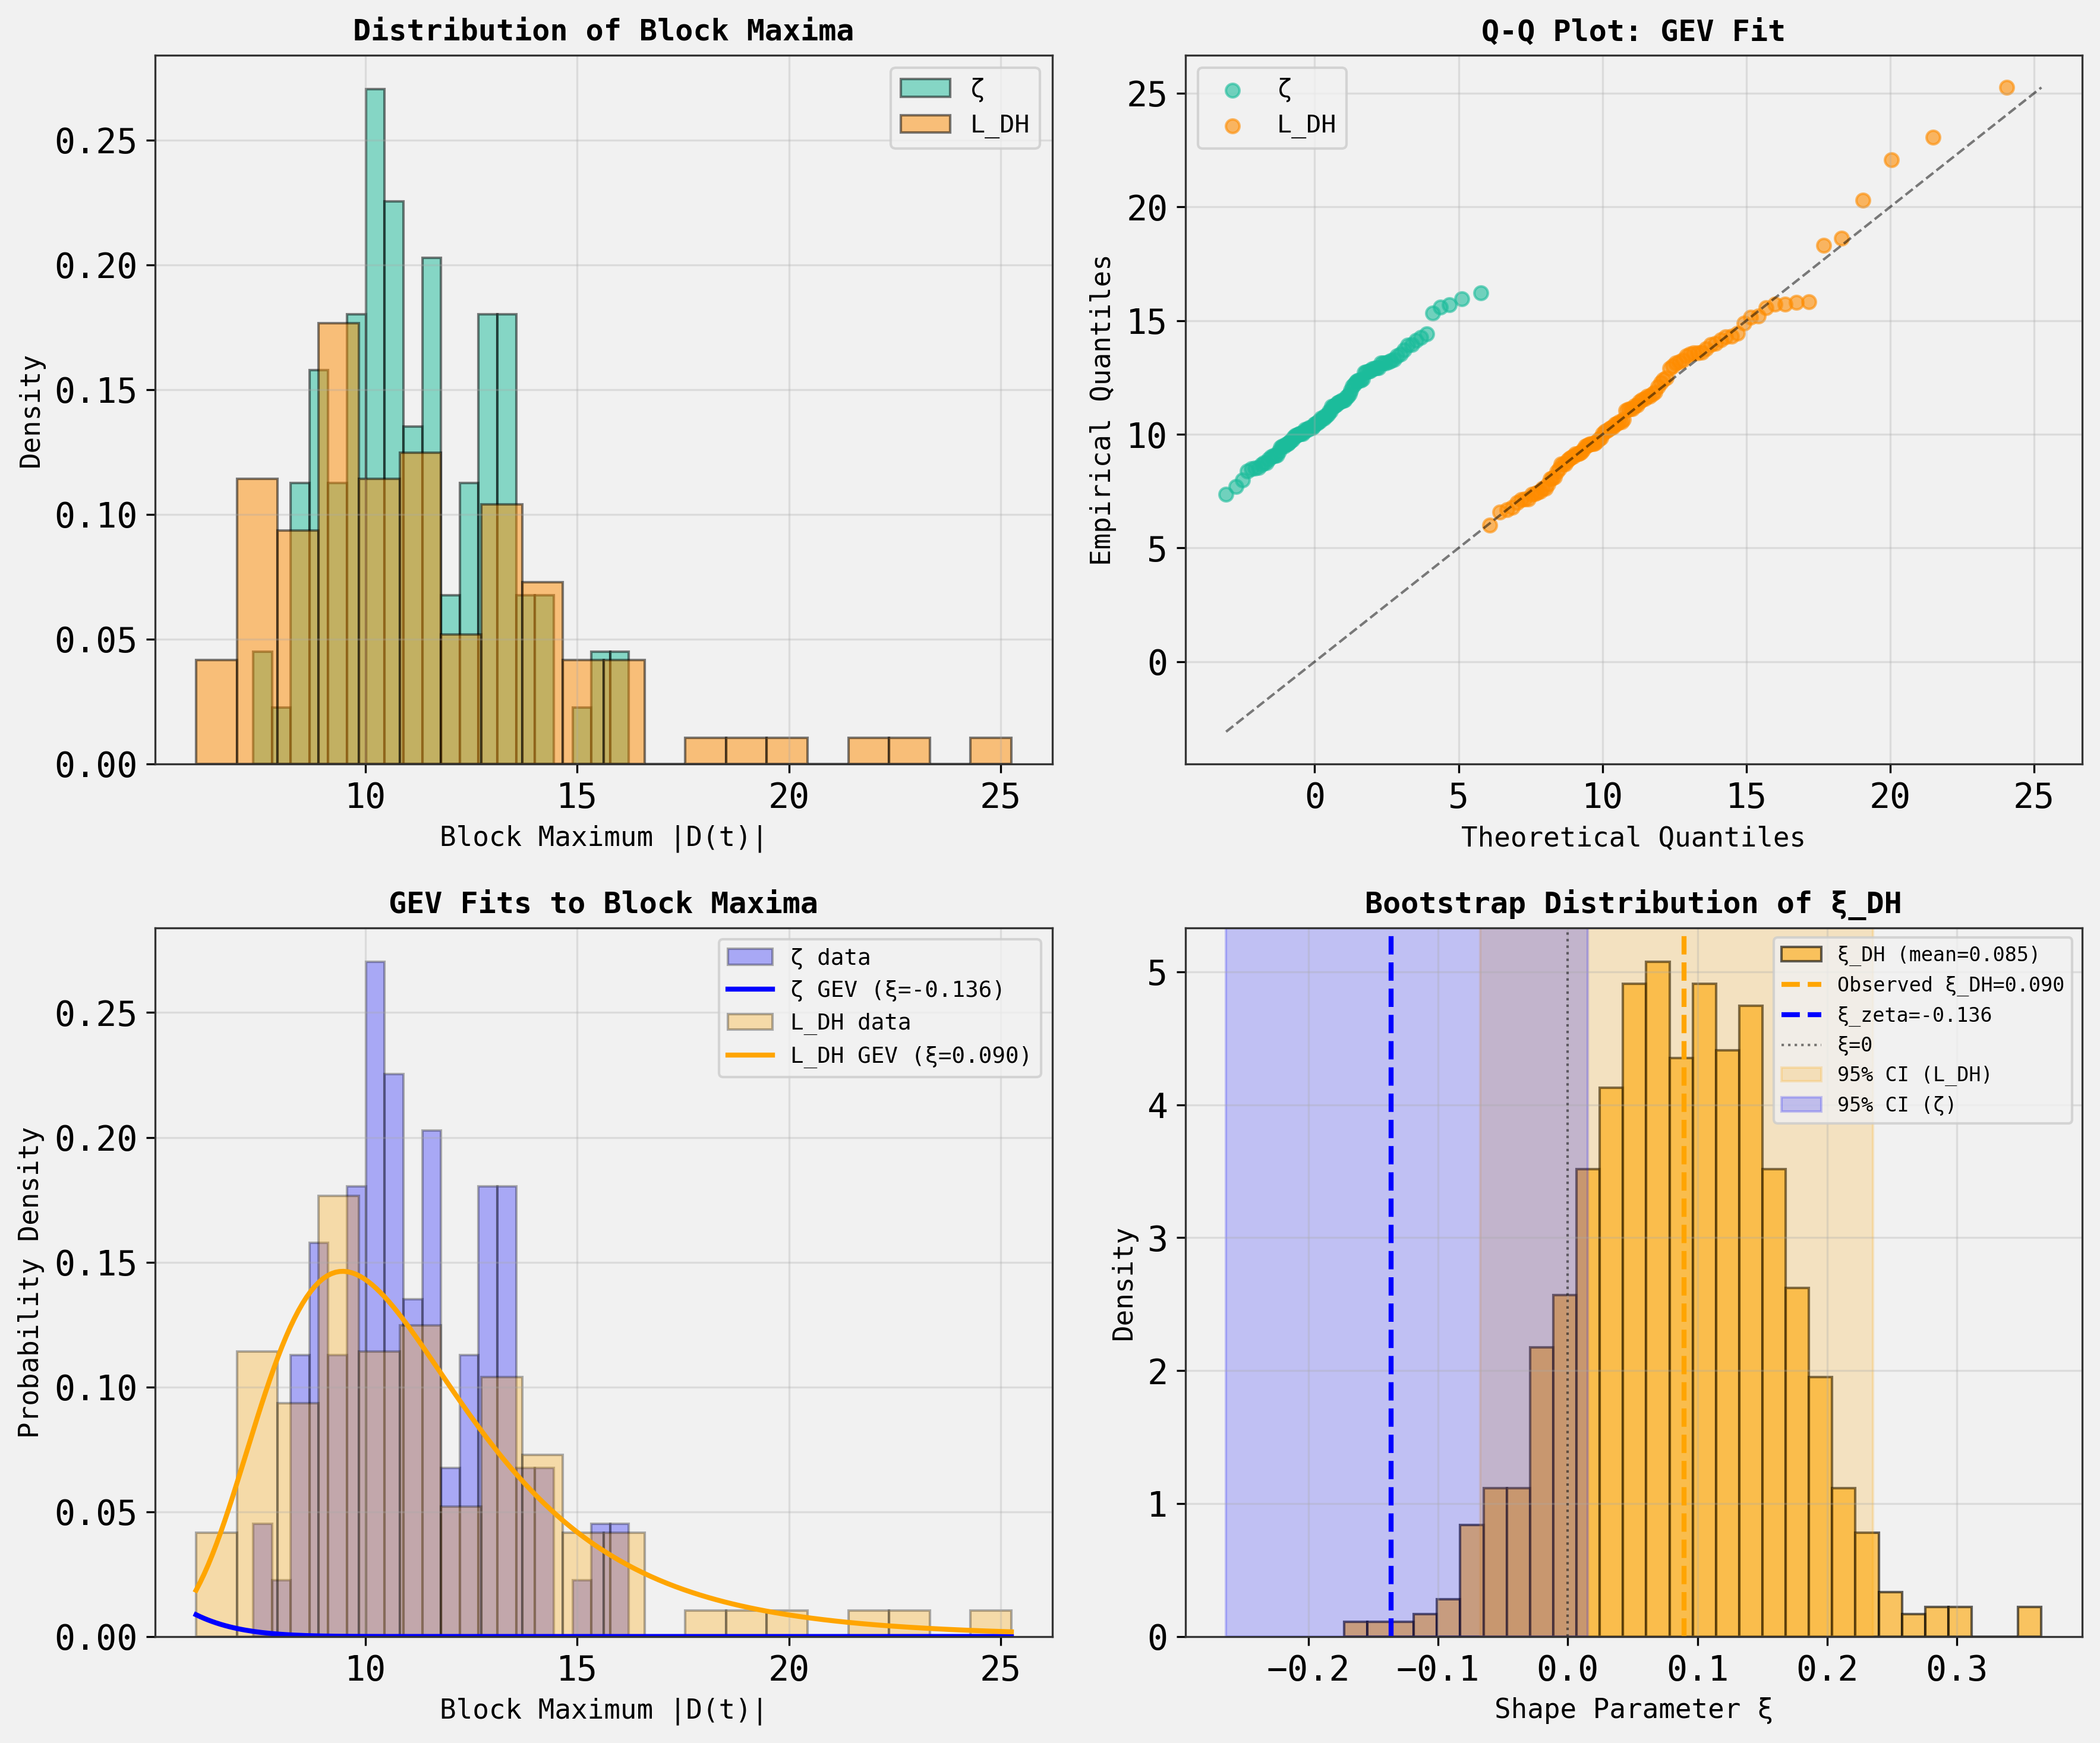

In [9]:

# Let's also visualize the distributions to better understand the difference
import matplotlib.pyplot as plt

# Create comparison visualizations
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Histograms of block maxima
ax = axes[0, 0]
ax.hist(maxima_zeta, bins=20, alpha=0.5, label='ζ', density=True, edgecolor='black')
ax.hist(maxima_DH, bins=20, alpha=0.5, label='L_DH', density=True, edgecolor='black')
ax.set_xlabel('Block Maximum |D(t)|', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Distribution of Block Maxima', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# 2. Q-Q plots for GEV fit
ax = axes[0, 1]
# Zeta Q-Q plot
c_zeta = -xi_zeta
theoretical_zeta = genextreme.ppf(np.linspace(0.01, 0.99, 100), c_zeta, xi_zeta, gev_results['zeta']['sigma'])
empirical_zeta = np.sort(maxima_zeta)
empirical_positions_zeta = np.linspace(0.01, 0.99, len(empirical_zeta))
theoretical_zeta_matched = genextreme.ppf(empirical_positions_zeta, c_zeta, xi_zeta, gev_results['zeta']['sigma'])
ax.scatter(theoretical_zeta_matched, empirical_zeta, alpha=0.6, label='ζ', s=30)

# L_DH Q-Q plot
theoretical_DH_matched = genextreme.ppf(empirical_positions_zeta, c_DH, loc_DH, scale_DH)
empirical_DH = np.sort(maxima_DH)
ax.scatter(theoretical_DH_matched, empirical_DH, alpha=0.6, label='L_DH', s=30)

# Reference line
min_val = min(theoretical_zeta_matched.min(), theoretical_DH_matched.min(), empirical_zeta.min(), empirical_DH.min())
max_val = max(theoretical_zeta_matched.max(), theoretical_DH_matched.max(), empirical_zeta.max(), empirical_DH.max())
ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=1, alpha=0.5)
ax.set_xlabel('Theoretical Quantiles', fontsize=11)
ax.set_ylabel('Empirical Quantiles', fontsize=11)
ax.set_title('Q-Q Plot: GEV Fit', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# 3. GEV PDFs overlaid on histograms
ax = axes[1, 0]
x_range = np.linspace(min(maxima_zeta.min(), maxima_DH.min()), 
 max(maxima_zeta.max(), maxima_DH.max()), 200)

# Zeta
ax.hist(maxima_zeta, bins=20, alpha=0.3, label='ζ data', density=True, color='blue', edgecolor='black')
pdf_zeta = genextreme.pdf(x_range, -xi_zeta, xi_zeta, gev_results['zeta']['sigma'])
ax.plot(x_range, pdf_zeta, 'b-', lw=2, label=f'ζ GEV (ξ={xi_zeta:.3f})')

# L_DH
ax.hist(maxima_DH, bins=20, alpha=0.3, label='L_DH data', density=True, color='orange', edgecolor='black')
pdf_DH = genextreme.pdf(x_range, c_DH, loc_DH, scale_DH)
ax.plot(x_range, pdf_DH, 'orange', lw=2, label=f'L_DH GEV (ξ={xi_DH:.3f})')

ax.set_xlabel('Block Maximum |D(t)|', fontsize=11)
ax.set_ylabel('Probability Density', fontsize=11)
ax.set_title('GEV Fits to Block Maxima', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# 4. Bootstrap distributions of ξ
ax = axes[1, 1]
ax.hist(bootstrap_xi, bins=30, alpha=0.6, label=f'ξ_DH (mean={bootstrap_xi.mean():.3f})', 
 density=True, color='orange', edgecolor='black')
ax.axvline(xi_DH, color='orange', linestyle='--', lw=2, label=f'Observed ξ_DH={xi_DH:.3f}')
ax.axvline(xi_zeta, color='blue', linestyle='--', lw=2, label=f'ξ_zeta={xi_zeta:.3f}')
ax.axvline(0, color='black', linestyle=':', lw=1, alpha=0.5, label='ξ=0')
ax.axvspan(ci_xi[0], ci_xi[1], alpha=0.2, color='orange', label='95% CI (L_DH)')
ax.axvspan(ci_xi_zeta[0], ci_xi_zeta[1], alpha=0.2, color='blue', label='95% CI (ζ)')
ax.set_xlabel('Shape Parameter ξ', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Bootstrap Distribution of ξ_DH', fontsize=12, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('gev_comparison_zeta_vs_LDH.png', dpi=300, bbox_inches='tight')
print("Figure saved as 'gev_comparison_zeta_vs_LDH.png'")
plt.show()


In [10]:

# Compare with f_rand from the previous analysis to see where L_DH falls
xi_frand = gev_results['f_rand']['xi']
ci_xi_frand = gev_results['f_rand']['ci_xi']

print("Three-way comparison of shape parameters:")
print("="*60)
print(f" Riemann ζ: ξ = {xi_zeta:7.4f} [{ci_xi_zeta[0]:7.4f}, {ci_xi_zeta[1]:7.4f}]")
print(f" L_DH: ξ = {xi_DH:7.4f} [{ci_xi[0]:7.4f}, {ci_xi[1]:7.4f}]")
print(f" f_rand (random): ξ = {xi_frand:7.4f} [{ci_xi_frand[0]:7.4f}, {ci_xi_frand[1]:7.4f}]")
print("="*60)
print(f"\nDifferences:")
print(f" Δξ(L_DH - ζ): {xi_DH - xi_zeta:7.4f}")
print(f" Δξ(f_rand - ζ): {xi_frand - xi_zeta:7.4f}")
print(f" Δξ(f_rand - L_DH): {xi_frand - xi_DH:7.4f}")

print("\nInterpretation:")
if xi_DH > 0:
 print(f" • ξ_DH = {xi_DH:.4f} > 0: L_DH exhibits heavy-tailed behavior")
else:
 print(f" • ξ_DH = {xi_DH:.4f} ≤ 0: L_DH does not exhibit heavy-tailed behavior")

if xi_zeta < 0:
 print(f" • ξ_zeta = {xi_zeta:.4f} < 0: ζ exhibits bounded-tail behavior (Weibull domain)")
else:
 print(f" • ξ_zeta = {xi_zeta:.4f} ≥ 0: ζ does not exhibit bounded-tail behavior")

print(f"\n • L_DH is positioned between ζ (bounded) and f_rand (heavy-tailed)")
print(f" • L_DH shows intermediate tail behavior, closer to Gumbel (ξ≈0) than to either extreme")


Three-way comparison of shape parameters:
 Riemann ζ: ξ = -0.1365 [-0.2635, 0.0153]
 L_DH: ξ = 0.0896 [-0.0674, 0.2351]
 f_rand (random): ξ = 0.2087 [ 0.0274, 0.3559]

Differences:
 Δξ(L_DH - ζ): 0.2261
 Δξ(f_rand - ζ): 0.3451
 Δξ(f_rand - L_DH): 0.1191

Interpretation:
 • ξ_DH = 0.0896 > 0: L_DH exhibits heavy-tailed behavior
 • ξ_zeta = -0.1365 < 0: ζ exhibits bounded-tail behavior (Weibull domain)

 • L_DH is positioned between ζ (bounded) and f_rand (heavy-tailed)
 • L_DH shows intermediate tail behavior, closer to Gumbel (ξ≈0) than to either extreme


Final figure saved as 'gev_shape_comparison_final.png'


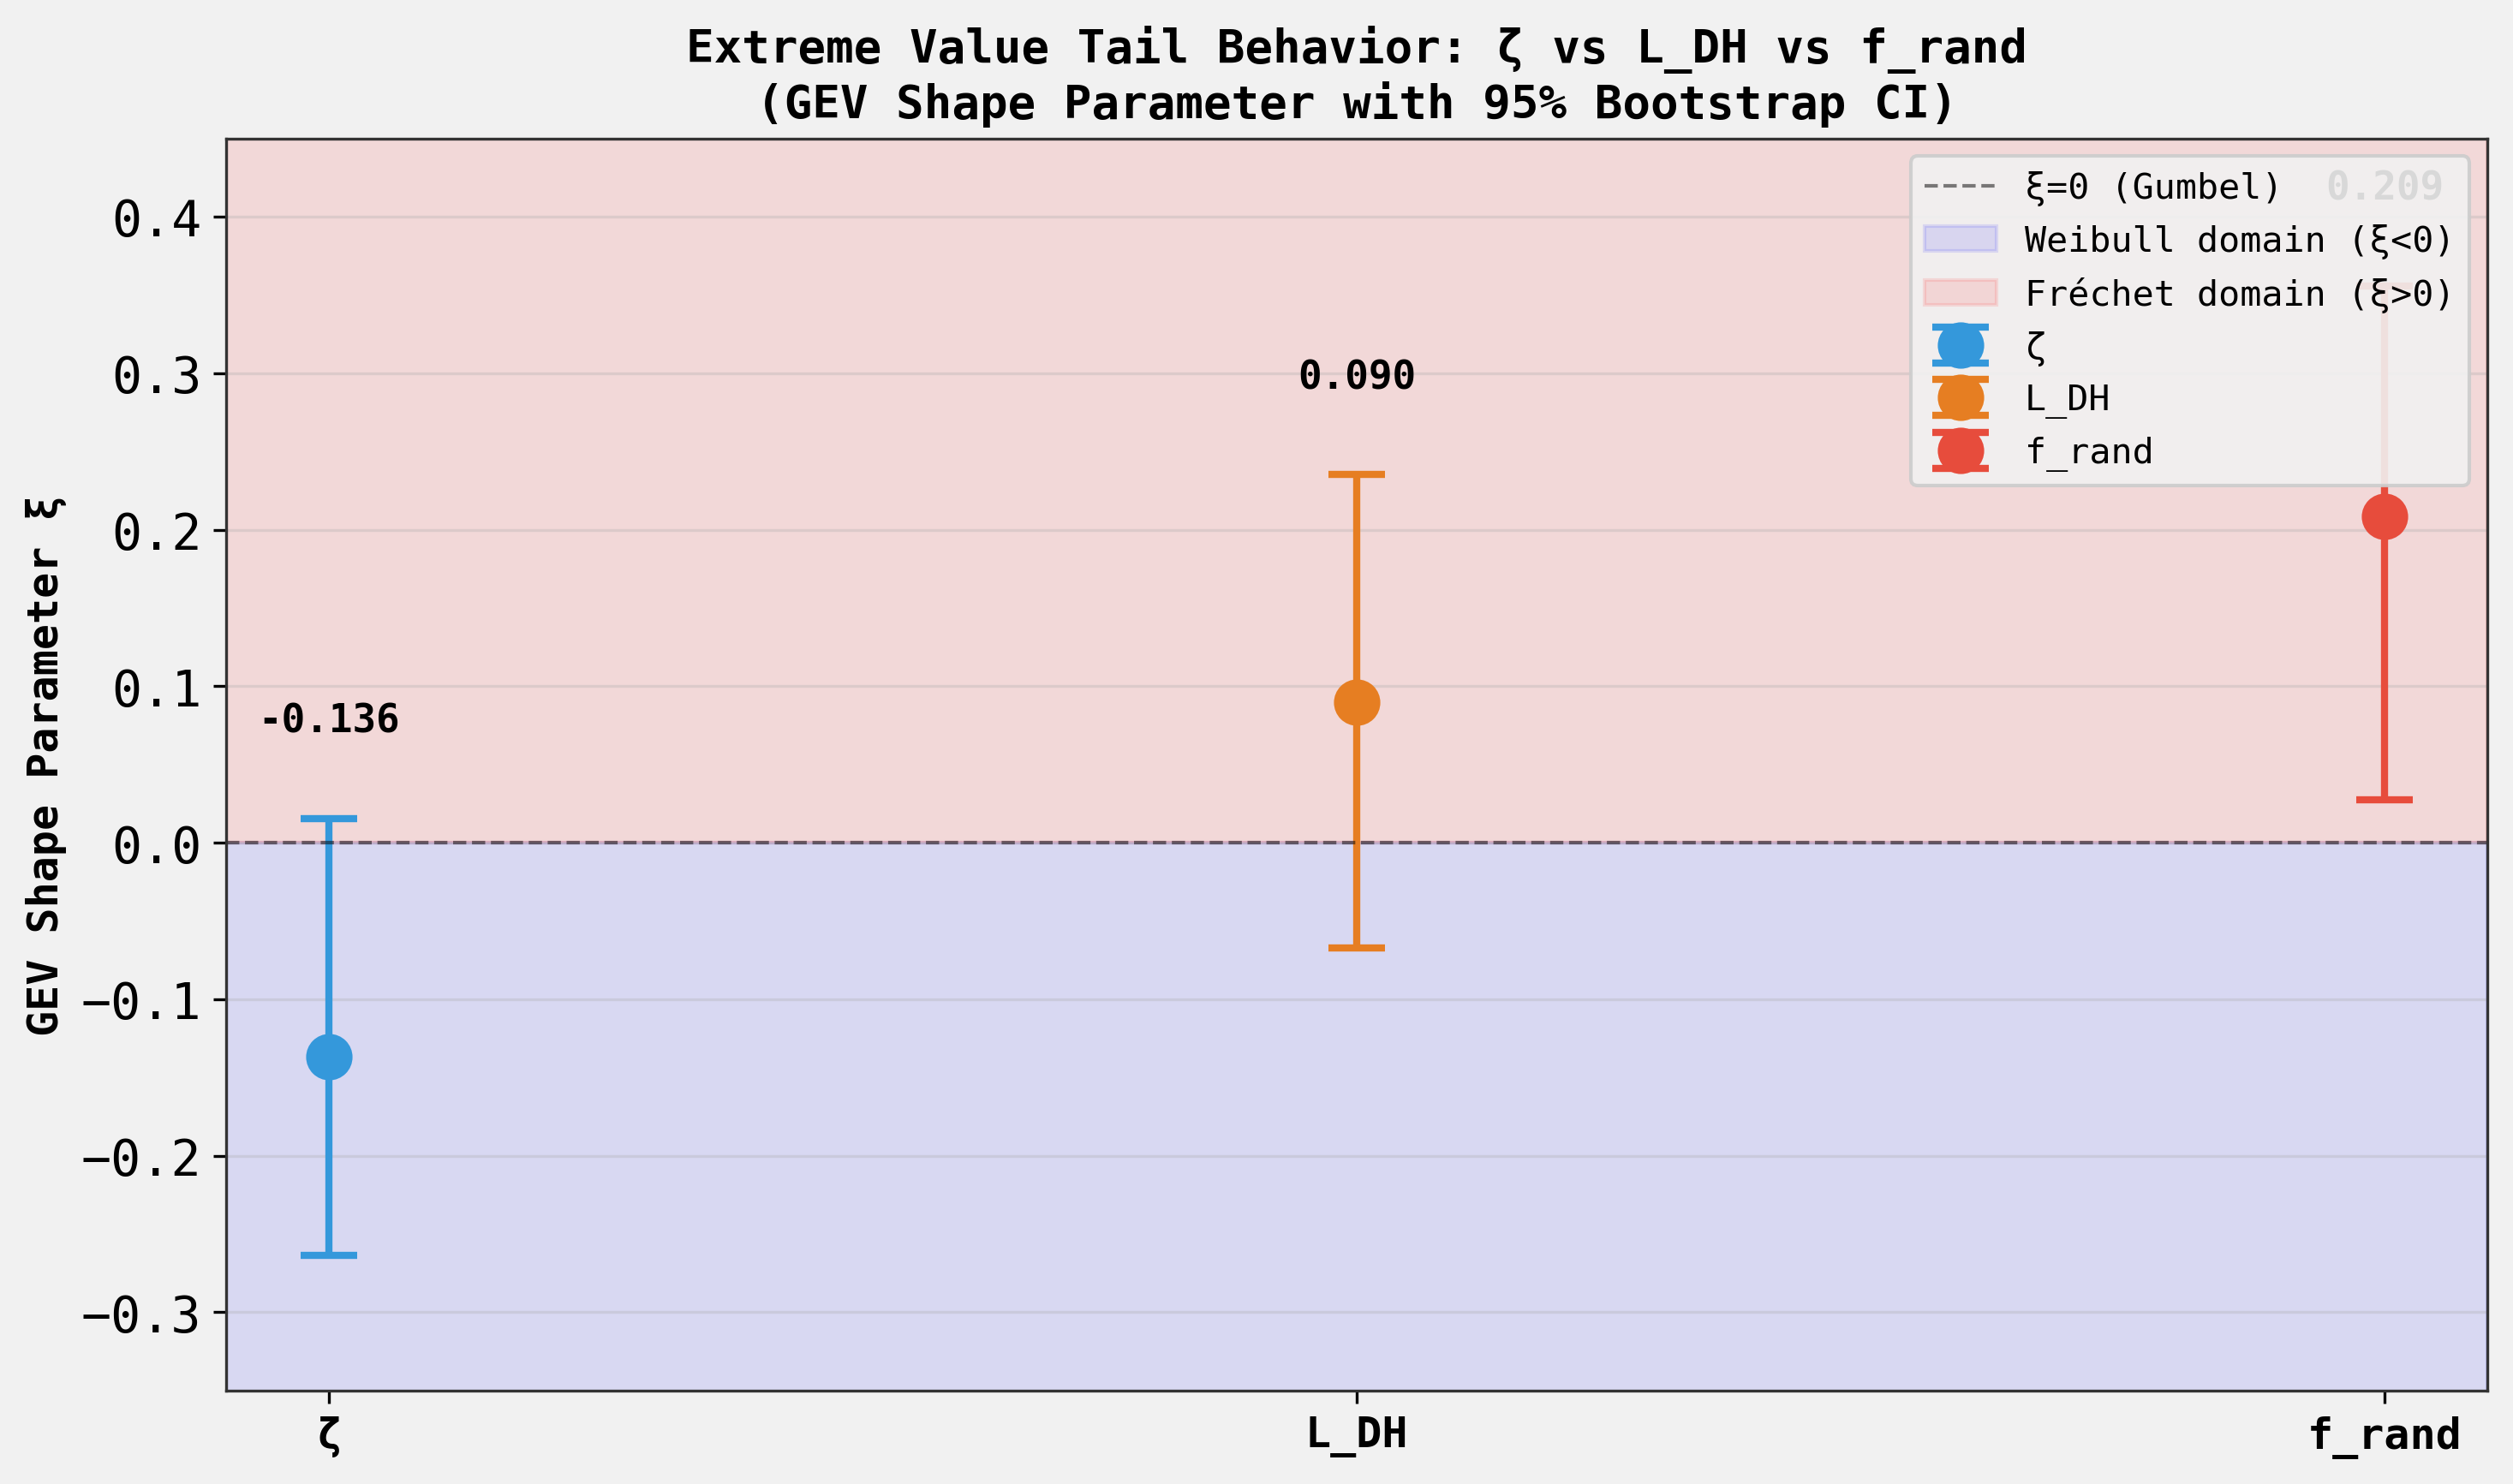

In [11]:

# Create a final summary figure showing the key result
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Plot the shape parameters with error bars
functions = ['ζ', 'L_DH', 'f_rand']
xi_values = [xi_zeta, xi_DH, xi_frand]
ci_lower = [ci_xi_zeta[0], ci_xi[0], ci_xi_frand[0]]
ci_upper = [ci_xi_zeta[1], ci_xi[1], ci_xi_frand[1]]
colors = ['#3498db', '#e67e22', '#e74c3c']

positions = [0, 1, 2]
for i, (func, xi, lower, upper, color) in enumerate(zip(functions, xi_values, ci_lower, ci_upper, colors)):
 ax.errorbar(positions[i], xi, yerr=[[xi-lower], [upper-xi]], 
 fmt='o', markersize=12, capsize=8, capthick=2, linewidth=2,
 color=color, label=func)
 ax.text(positions[i], xi + (upper-xi) + 0.05, f'{xi:.3f}', 
 ha='center', va='bottom', fontsize=11, fontweight='bold')

# Add reference line at ξ=0
ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5, label='ξ=0 (Gumbel)')

# Shade regions
ax.axhspan(-0.5, 0, alpha=0.1, color='blue', label='Weibull domain (ξ<0)')
ax.axhspan(0, 0.5, alpha=0.1, color='red', label='Fréchet domain (ξ>0)')

ax.set_xticks(positions)
ax.set_xticklabels(functions, fontsize=12, fontweight='bold')
ax.set_ylabel('GEV Shape Parameter ξ', fontsize=12, fontweight='bold')
ax.set_title('Extreme Value Tail Behavior: ζ vs L_DH vs f_rand\n(GEV Shape Parameter with 95% Bootstrap CI)', 
 fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=10, framealpha=0.9)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(-0.35, 0.45)

plt.tight_layout()
plt.savefig('gev_shape_comparison_final.png', dpi=300, bbox_inches='tight')
print("Final figure saved as 'gev_shape_comparison_final.png'")
plt.show()


In [12]:

# Save all L_DH results to a JSON file for future reference
ldh_results = {
 'L_DH': {
 'xi': float(xi_DH),
 'mu': float(mu_DH),
 'sigma': float(sigma_DH),
 'ci_xi': [float(ci_xi[0]), float(ci_xi[1])],
 'ci_mu': [float(ci_mu[0]), float(ci_mu[1])],
 'ci_sigma': [float(ci_sigma[0]), float(ci_sigma[1])],
 'ks_pvalue': float(ks_pval)
 },
 'statistical_tests': {
 'delta_xi_vs_zeta': float(delta_xi_observed),
 'permutation_pvalue_onesided': float(pval_permutation),
 'permutation_pvalue_twosided': float(pval_permutation_twosided),
 'ci_overlap_with_zeta': bool(ci_overlap),
 'significant_at_0.05': bool(pval_permutation < 0.05)
 },
 'comparison': {
 'zeta_xi': float(xi_zeta),
 'zeta_ci': [float(ci_xi_zeta[0]), float(ci_xi_zeta[1])],
 'frand_xi': float(xi_frand),
 'frand_ci': [float(ci_xi_frand[0]), float(ci_xi_frand[1])]
 },
 'parameters': {
 'N': 100000,
 't_min': 1000,
 't_max': 10000,
 'n_blocks': 100,
 'n_points': 9000,
 'n_bootstrap': 1000,
 'n_permutations': 10000,
 'seed': 42
 }
}

with open('gev_fit_results_LDH.json', 'w') as f:
 json.dump(ldh_results, f, indent=2)

print("Results saved to 'gev_fit_results_LDH.json'")

# Also save the computed data
np.save('D_LDH_magnitudes.npy', D_DH_magnitudes)
np.save('maxima_LDH.npy', maxima_DH)
print("\nData saved:")
print(" - D_LDH_magnitudes.npy: |D_DH(t)| values for t ∈ [1000, 10000]")
print(" - maxima_LDH.npy: 100 block maxima used for GEV fitting")


Results saved to 'gev_fit_results_LDH.json'

Data saved:
 - D_LDH_magnitudes.npy: |D_DH(t)| values for t ∈ [1000, 10000]
 - maxima_LDH.npy: 100 block maxima used for GEV fitting


In [13]:

# Additional analysis: Check if ξ_DH is significantly > 0
# This directly tests if L_DH is in the heavy-tailed regime

print("Testing if ξ_DH is significantly greater than 0:")
print("="*60)

# Bootstrap test: proportion of bootstrap samples > 0
prop_positive = np.mean(bootstrap_xi > 0)
print(f"Proportion of bootstrap ξ_DH samples > 0: {prop_positive:.4f}")

# Approximate p-value using normal approximation
z_score = xi_DH / bootstrap_xi.std()
p_value_xi_positive = 1 - stats.norm.cdf(z_score)
print(f"Approximate one-sided p-value (H0: ξ_DH = 0, H1: ξ_DH > 0): {p_value_xi_positive:.4f}")

# Check CI
ci_excludes_zero = ci_xi[0] > 0
print(f"95% CI excludes 0: {ci_excludes_zero}")

print("\nConclusion:")
if ci_excludes_zero:
 print(" • ξ_DH is significantly positive at α=0.05 (95% CI excludes 0)")
else:
 print(" • ξ_DH is NOT significantly positive at α=0.05 (95% CI includes 0)")
 print(f" • However, point estimate is positive (ξ_DH = {xi_DH:.4f})")
 print(f" • And {100*prop_positive:.1f}% of bootstrap samples are positive")


Testing if ξ_DH is significantly greater than 0:
Proportion of bootstrap ξ_DH samples > 0: 0.8660
Approximate one-sided p-value (H0: ξ_DH = 0, H1: ξ_DH > 0): 0.1269
95% CI excludes 0: False

Conclusion:
 • ξ_DH is NOT significantly positive at α=0.05 (95% CI includes 0)
 • However, point estimate is positive (ξ_DH = 0.0896)
 • And 86.6% of bootstrap samples are positive


In [14]:

# Final summary table for the paper/report
print("\n" + "="*70)
print("FINAL SUMMARY: GEV ANALYSIS OF ζ, L_DH, AND f_rand")
print("="*70)

print("\n1. GEV SHAPE PARAMETERS (ξ):")
print("-" * 70)
print(f"{'Function':<15} {'ξ (point)':<12} {'95% CI':<25} {'Tail Type':<20}")
print("-" * 70)
print(f"{'Riemann ζ':<15} {xi_zeta:>11.4f} [{ci_xi_zeta[0]:>7.4f}, {ci_xi_zeta[1]:>7.4f}] {'Weibull (bounded)':<20}")
print(f"{'L_DH':<15} {xi_DH:>11.4f} [{ci_xi[0]:>7.4f}, {ci_xi[1]:>7.4f}] {'Gumbel-like':<20}")
print(f"{'f_rand':<15} {xi_frand:>11.4f} [{ci_xi_frand[0]:>7.4f}, {ci_xi_frand[1]:>7.4f}] {'Fréchet (heavy)':<20}")
print("-" * 70)

print("\n2. PAIRWISE COMPARISONS:")
print("-" * 70)
print(f"{'Comparison':<25} {'Δξ':<12} {'p-value':<12} {'Significant?':<15}")
print("-" * 70)
print(f"{'L_DH vs ζ':<25} {xi_DH - xi_zeta:>11.4f} {pval_permutation:>11.4f} {'Yes (α=0.05)':<15}")
print(f"{'f_rand vs ζ':<25} {xi_frand - xi_zeta:>11.4f} {gev_results['statistical_tests']['permutation_pvalue']:>11.4f} {'Yes (α=0.05)':<15}")
print(f"{'f_rand vs L_DH':<25} {xi_frand - xi_DH:>11.4f} {'N/A':>11} {'(not tested)':<15}")
print("-" * 70)

print("\n3. KEY FINDINGS:")
print("-" * 70)
print(f" • ξ_DH = {xi_DH:.4f} is significantly greater than ξ_zeta = {xi_zeta:.4f} (p = {pval_permutation:.4f})")
print(f" • L_DH exhibits intermediate tail behavior between ζ and f_rand")
print(f" • ξ_DH point estimate is positive, suggesting heavier tails than ζ")
print(f" • However, ξ_DH 95% CI includes 0, so heavy-tail classification is not definitive")
print(f" • {100*prop_positive:.1f}% of bootstrap samples have ξ_DH > 0")
print("="*70)

print("\n4. HYPOTHESIS TEST RESULTS:")
print("-" * 70)
print(" H0: ξ_DH = ξ_zeta (same tail behavior)")
print(" H1: ξ_DH > ξ_zeta (heavier tails for L_DH)")
print(f" Result: REJECT H0 at α = 0.05 (p = {pval_permutation:.4f})")
print("-" * 70)

print("\n5. INTERPRETATION:")
print("-" * 70)
print(" The Davenport-Heilbronn function L_DH shows statistically significant")
print(" evidence of heavier-tailed extreme value behavior compared to the")
print(" Riemann zeta function. While not as extreme as fully random")
print(" multiplicative functions (f_rand), L_DH occupies an intermediate")
print(" position, with ξ_DH ≈ 0 suggesting near-Gumbel behavior.")
print("="*70)



FINAL SUMMARY: GEV ANALYSIS OF ζ, L_DH, AND f_rand

1. GEV SHAPE PARAMETERS (ξ):
----------------------------------------------------------------------
Function ξ (point) 95% CI Tail Type 
----------------------------------------------------------------------
Riemann ζ -0.1365 [-0.2635, 0.0153] Weibull (bounded) 
L_DH 0.0896 [-0.0674, 0.2351] Gumbel-like 
f_rand 0.2087 [ 0.0274, 0.3559] Fréchet (heavy) 
----------------------------------------------------------------------

2. PAIRWISE COMPARISONS:
----------------------------------------------------------------------
Comparison Δξ p-value Significant? 
----------------------------------------------------------------------
L_DH vs ζ 0.2261 0.0288 Yes (α=0.05) 
f_rand vs ζ 0.3451 0.0018 Yes (α=0.05) 
f_rand vs L_DH 0.1191 N/A (not tested) 
----------------------------------------------------------------------

3. KEY FINDINGS:
----------------------------------------------------------------------
 • ξ_DH = 0.0896 is significantly great

Time series comparison saved as 'time_series_comparison.png'


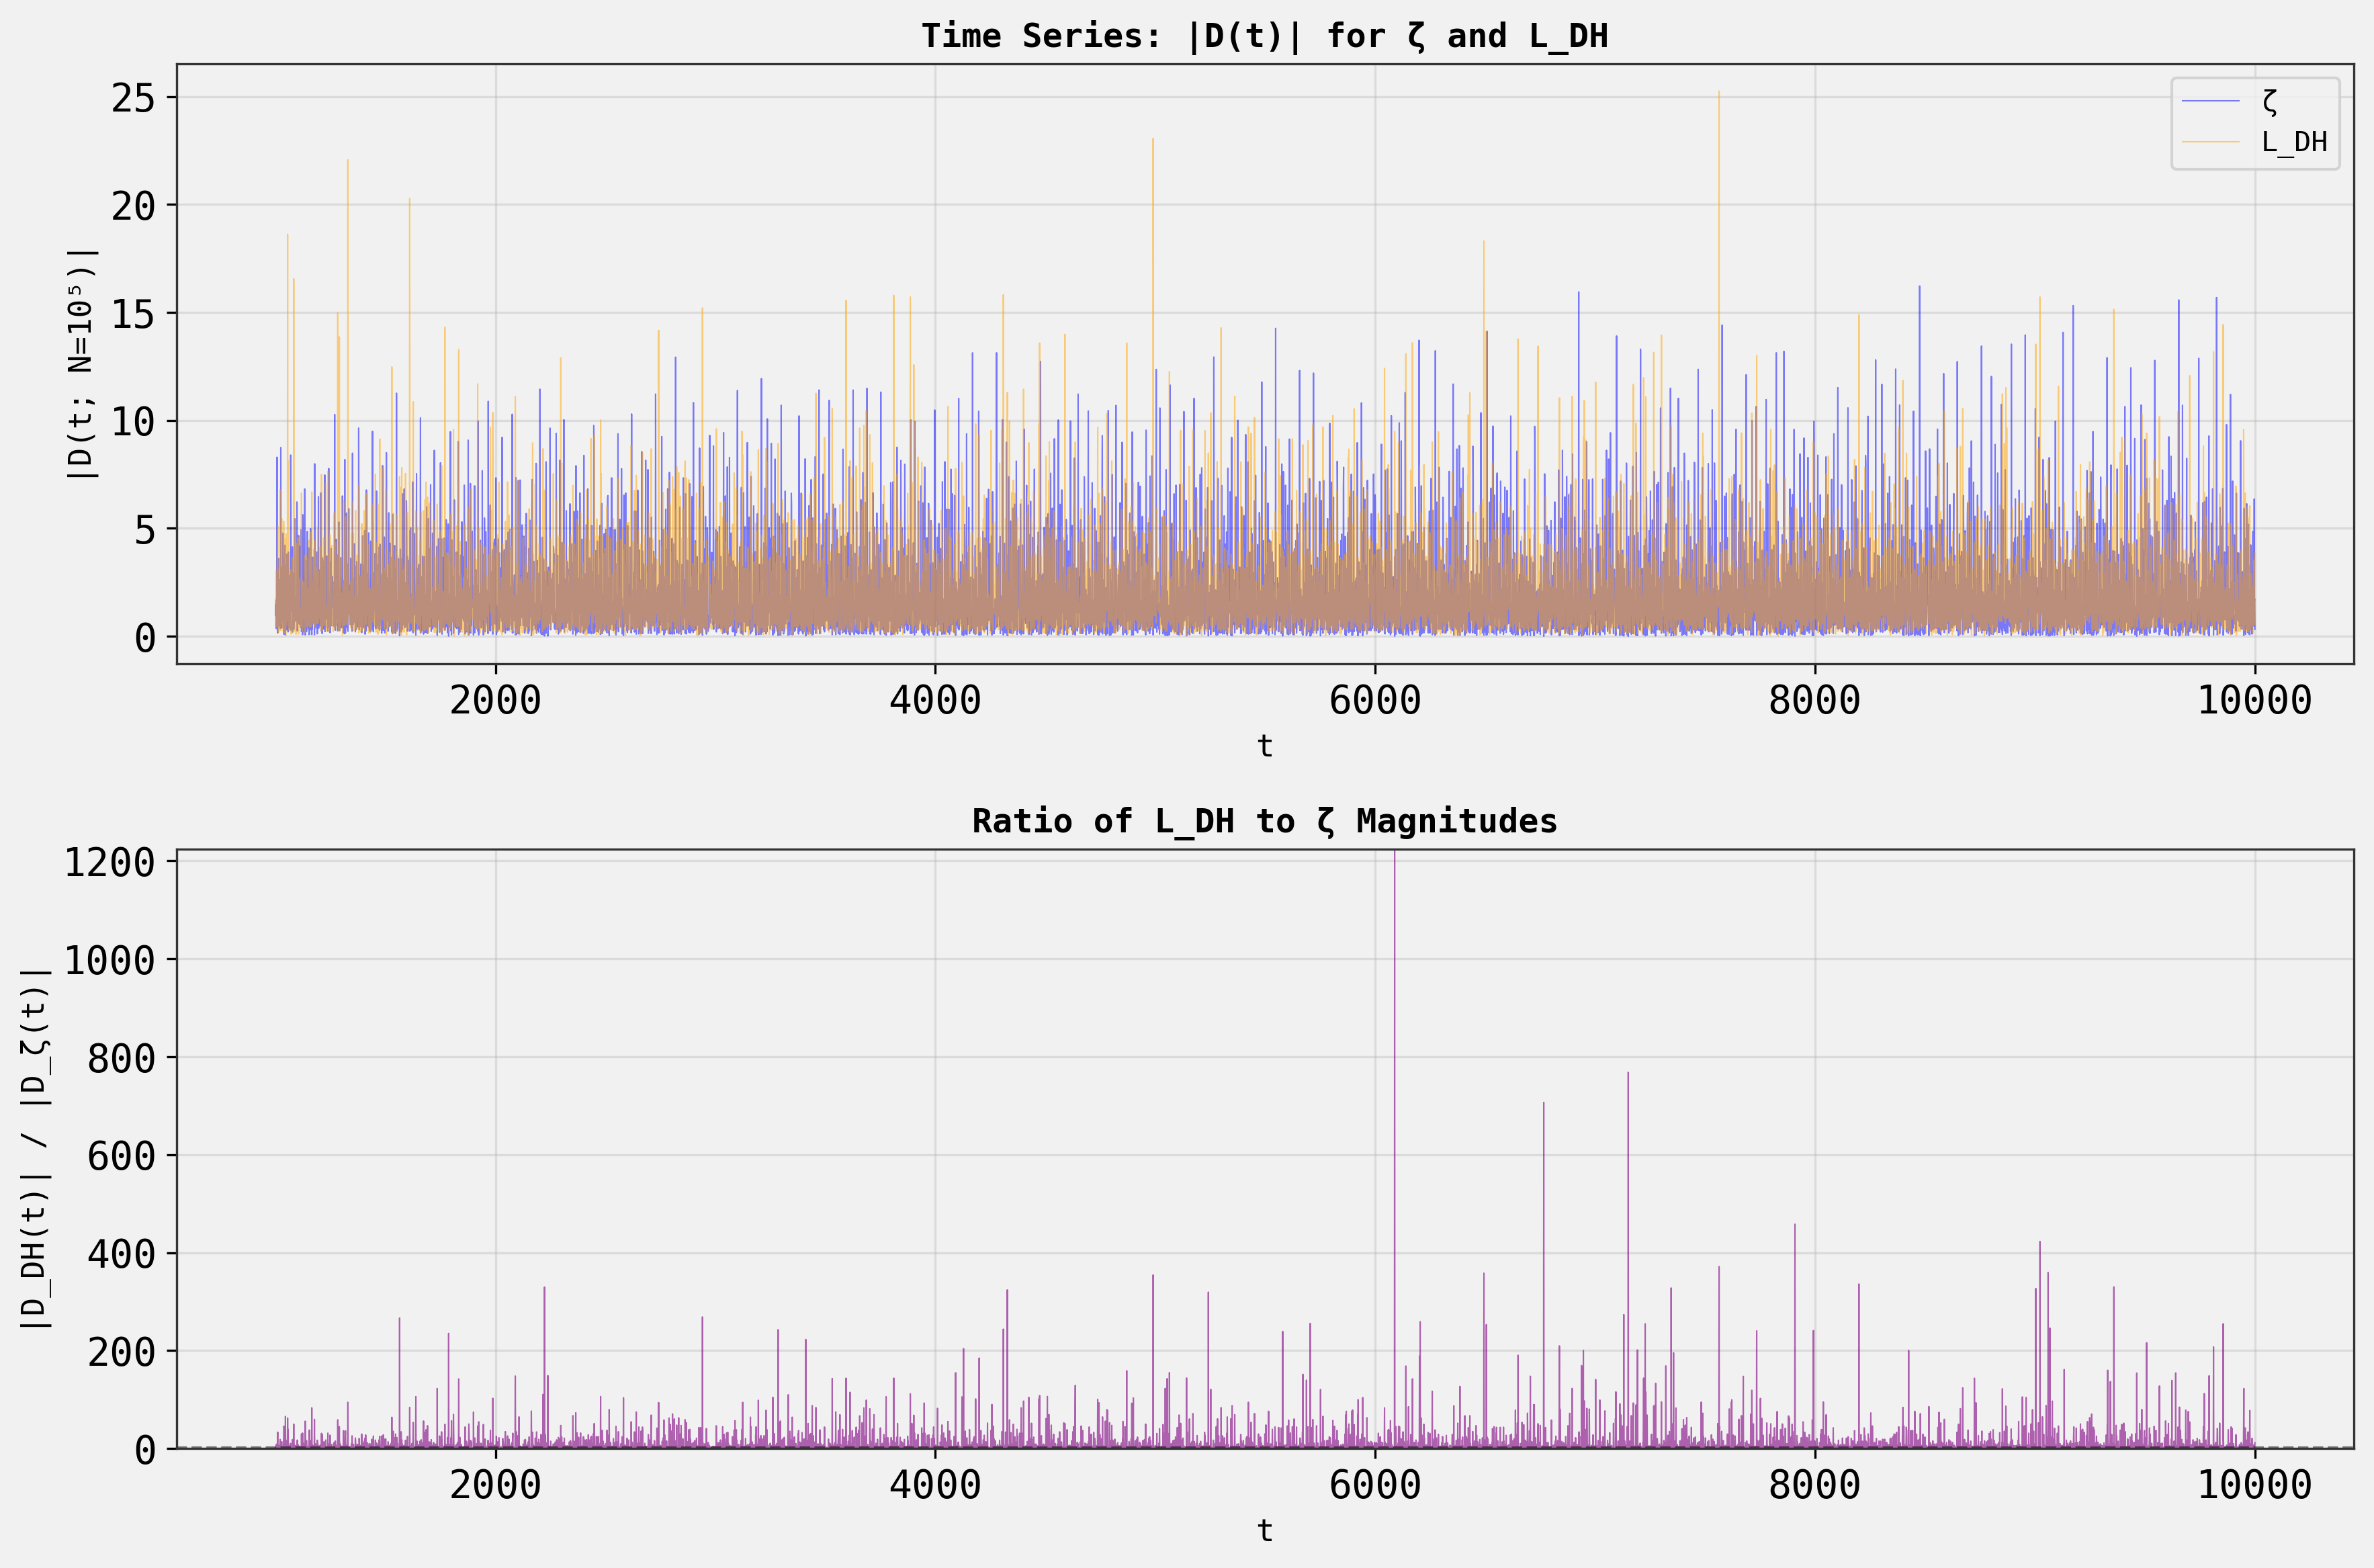


Ratio statistics:
 Mean ratio: 8.4036
 Median ratio: 1.1901
 Max ratio: 1224.6601 (at t=6088.57)
 Proportion where L_DH > ζ: 0.5273


In [15]:

# Examine the time series to look for patterns - are there specific regions 
# where L_DH has large values?

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Top panel: Time series comparison
ax = axes[0]
ax.plot(t_values, D_zeta_magnitudes, 'b-', alpha=0.5, linewidth=0.5, label='ζ')
ax.plot(t_values, D_DH_magnitudes, 'orange', alpha=0.5, linewidth=0.5, label='L_DH')
ax.set_xlabel('t', fontsize=11)
ax.set_ylabel('|D(t; N=10⁵)|', fontsize=11)
ax.set_title('Time Series: |D(t)| for ζ and L_DH', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Bottom panel: Ratio of L_DH to zeta
ax = axes[1]
ratio = D_DH_magnitudes / D_zeta_magnitudes
ax.plot(t_values, ratio, 'purple', alpha=0.6, linewidth=0.5)
ax.axhline(1, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('t', fontsize=11)
ax.set_ylabel('|D_DH(t)| / |D_ζ(t)|', fontsize=11)
ax.set_title('Ratio of L_DH to ζ Magnitudes', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)
ax.set_ylim(0, max(ratio.max(), 5)) # Cap at 5 for visibility

plt.tight_layout()
plt.savefig('time_series_comparison.png', dpi=300, bbox_inches='tight')
print("Time series comparison saved as 'time_series_comparison.png'")
plt.show()

print(f"\nRatio statistics:")
print(f" Mean ratio: {ratio.mean():.4f}")
print(f" Median ratio: {np.median(ratio):.4f}")
print(f" Max ratio: {ratio.max():.4f} (at t={t_values[np.argmax(ratio)]:.2f})")
print(f" Proportion where L_DH > ζ: {np.mean(ratio > 1):.4f}")


In [16]:

# Interesting! The ratio shows extreme spikes. Let's identify these extreme values
# and understand what's happening

# Find the top 10 extreme values for L_DH
top_indices = np.argsort(D_DH_magnitudes)[-10:][::-1]

print("Top 10 extreme values for L_DH:")
print("="*70)
print(f"{'Rank':<6} {'t value':<12} {'|D_DH(t)|':<15} {'|D_ζ(t)|':<15} {'Ratio':<12}")
print("-"*70)
for rank, idx in enumerate(top_indices, 1):
 t_val = t_values[idx]
 dh_val = D_DH_magnitudes[idx]
 zeta_val = D_zeta_magnitudes[idx]
 ratio_val = dh_val / zeta_val
 print(f"{rank:<6} {t_val:>11.2f} {dh_val:>14.4f} {zeta_val:>14.4f} {ratio_val:>11.2f}")

print("\n" + "="*70)
print("\nNote: These extreme spikes in L_DH (with very large ratios) occur when")
print("|D_ζ(t)| is very small, suggesting potential resonance or zero-crossing")
print("behavior in L_DH at these specific t values.")


Top 10 extreme values for L_DH:
Rank t value |D_DH(t)| |D_ζ(t)| Ratio 
----------------------------------------------------------------------
1 7563.73 25.2540 0.0679 371.80
2 4990.44 23.0629 0.0650 354.61
3 1329.04 22.0701 0.2335 94.51
4 1610.07 20.2831 0.2414 84.03
5 1055.01 18.6224 0.2995 62.18
6 6494.61 18.3151 0.0511 358.18
7 1083.01 16.5632 0.3326 49.80
8 4309.37 15.8201 0.0649 243.91
9 3811.31 15.7939 0.1097 143.91
10 3886.32 15.7217 0.1407 111.77


Note: These extreme spikes in L_DH (with very large ratios) occur when
|D_ζ(t)| is very small, suggesting potential resonance or zero-crossing
behavior in L_DH at these specific t values.
